In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
import xgboost
import matplotlib.pyplot as plt

# Exploratory Analysis

In [92]:
url = "https://raw.githubusercontent.com/AbrahamNFernandezM/Hiring-prediction-xgboost/refs/heads/main/Data/recruitment_data.csv"
df = pd.read_csv(url)

In [93]:
df.shape

(1500, 11)

In [8]:
df.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [12]:
df_datatype = pd.DataFrame({
    "Variable": df.columns,
    "Data type": df.dtypes.astype(str)
})

print(df_datatype.to_markdown(index=False))

| Variable            | Data type   |
|:--------------------|:------------|
| Age                 | int64       |
| Gender              | int64       |
| EducationLevel      | int64       |
| ExperienceYears     | int64       |
| PreviousCompanies   | int64       |
| DistanceFromCompany | float64     |
| InterviewScore      | int64       |
| SkillScore          | int64       |
| PersonalityScore    | int64       |
| RecruitmentStrategy | int64       |
| HiringDecision      | int64       |


In [14]:
nulls = df.isnull().sum() / len(df)*100
nulls_tab = pd.DataFrame({
    "Variable": nulls.index,
    "nulls %": nulls.values
})
print(nulls_tab.to_markdown(index=False))

| Variable            |   nulls % |
|:--------------------|----------:|
| Age                 |         0 |
| Gender              |         0 |
| EducationLevel      |         0 |
| ExperienceYears     |         0 |
| PreviousCompanies   |         0 |
| DistanceFromCompany |         0 |
| InterviewScore      |         0 |
| SkillScore          |         0 |
| PersonalityScore    |         0 |
| RecruitmentStrategy |         0 |
| HiringDecision      |         0 |


In [21]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


# Model Training

In [22]:
X = df.loc[:,df.columns!="HiringDecision"]

In [24]:
y = df.loc[:,df.columns=="HiringDecision"]

In [32]:
print("X shape:",X.shape,"| y shape:", y.shape, "| (full) df:",df.shape)

X shape: (1500, 10) | y shape: (1500, 1) | (full) df: (1500, 11)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) 

In [42]:
model = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Model Testing

In [43]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [72]:
Accuracy = accuracy_score(y_test, y_pred)
Logloss = log_loss(y_test,y_prob)
AUC = roc_auc_score(y_test,y_prob[:,1])

metrics = {
    "Métric":["Accuracy","Logloss","AUC"],
    "Result": [Accuracy,Logloss,AUC]
}
metrics_tab = pd.DataFrame(metrics)
print(metrics_tab.to_markdown(index=False))

| Métric   |   Result |
|:---------|---------:|
| Accuracy | 0.944444 |
| Logloss  | 0.223232 |
| AUC      | 0.960651 |


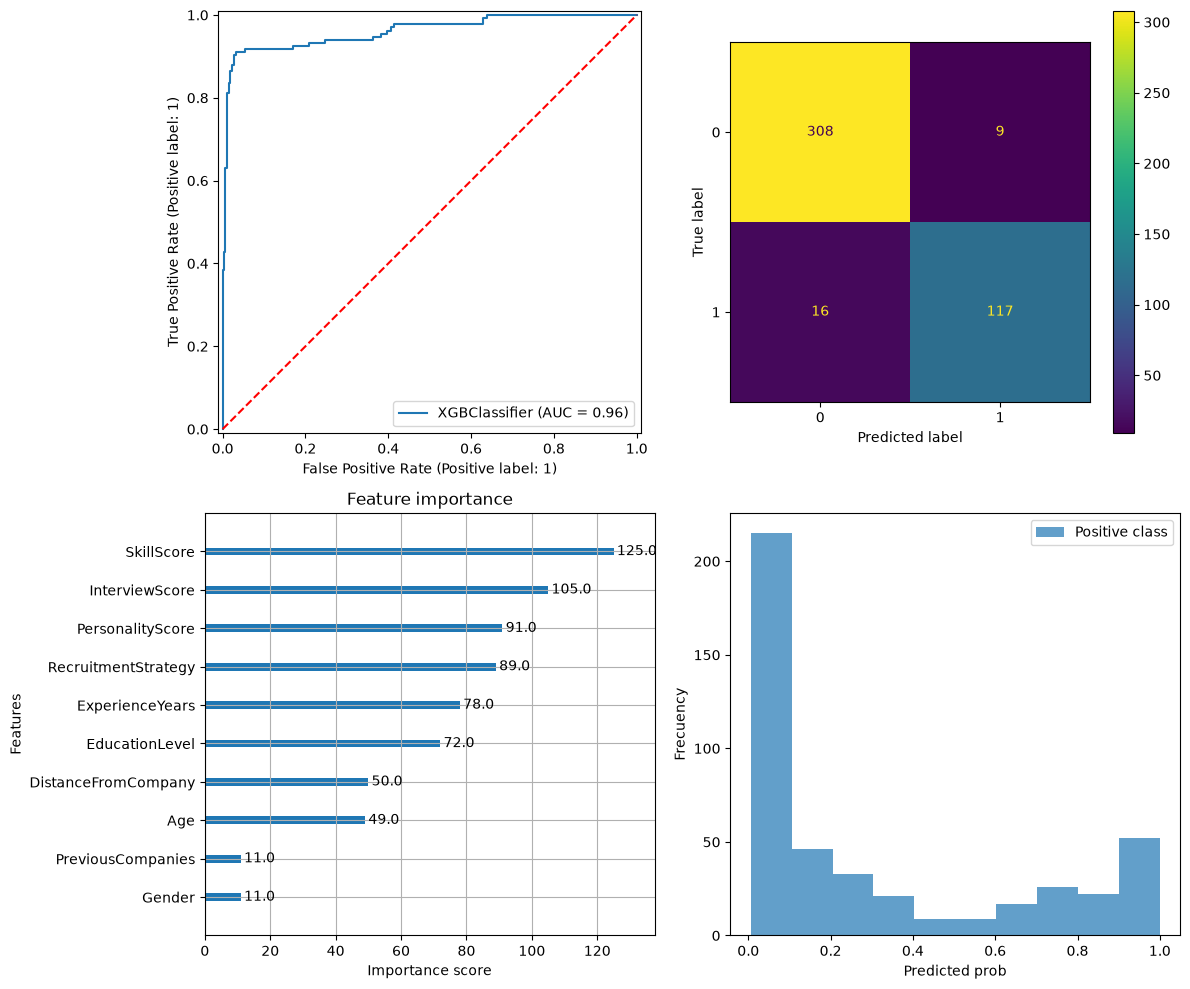

In [86]:
fig, axs = plt.subplots(2,2, figsize=(12,10))

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axs[0,0])
axs[0,0].plot([0,1],[0,1], linestyle="--", color="red")

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axs[0,1])

xgboost.plot_importance(model, ax=axs[1,0], importance_type="weight")

axs[1,1].hist(y_prob[:,1], bins=10, alpha=0.7, label="Positive class")
axs[1,1].set_xlabel("Predicted prob")
axs[1,1].set_ylabel("Frecuency")
axs[1,1].legend()

plt.tight_layout()
plt.show()